# Lesson 2 — Distributions: shape, skew & outliers

*Part 1 · Lesson 2 of 20  ·  data: Old Faithful · Lending Club*

**←** [Lesson 1: Describing a real dataset](01-describing-data.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb) **→**

**Same idea, another way:**  [Another dataset →](02-distributions-shape-outliers~another-dataset.ipynb)  ·  [The code behind it →](02-distributions-shape-outliers~the-code.ipynb)

In Lesson 1 we summarized penguins with a few numbers. Now we'll see those same numbers **lie** — gently, and sometimes spectacularly. We'll watch a geyser whose "average eruption" almost never happens, and meet incomes so lopsided that the mean and the median tell different stories. Along the way: histograms, skew, the outlier rule, and which statistics survive a billionaire.

Run each grey cell with **Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()

# Two datasets this lesson:
faithful = sl.load_csv('faithful.csv',
                       url='https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
loans = sl.load_csv('loans.csv',
                    url='https://www.openintro.org/data/csv/loans_full_schema.csv')

print(f"Old Faithful: {len(faithful)} eruptions, columns {list(faithful.columns)}")
print(f"Lending Club: {len(loans):,} loans")
faithful.head()

Old Faithful: 272 eruptions, columns ['rownames', 'eruptions', 'waiting']
Lending Club: 10,000 loans


,rownames,eruptions,waiting
0,1,3.600,79
1,2,1.800,54
2,3,3.333,74
3,4,2.283,62
4,5,4.533,85


## 1) A frequency table — counting by bins

The simplest way to *see* a distribution is to chop the number line into equal slices ("bins") and count how many values fall in each. That count is a **frequency table**, and it is exactly what a histogram draws.

- **The math:** pick bin edges, then for each bin count $f_k = $ (number of values $x$ with edge$_k \le x < $ edge$_{k+1}$).
- **The meaning:** each $f_k$ is a tally — how *crowded* that slice of the number line is.
- **The interpretation:** the *pattern* of the tallies is the shape of the data. One hump, two humps, a long tail — the table already hints at it before we draw anything.

Let's tally Old Faithful's eruption lengths (in minutes).

In [2]:
e = faithful['eruptions']                       # eruption length, minutes
edges = np.arange(1.5, 5.5 + 0.5, 0.5)          # bin edges every half-minute
table = pd.cut(e, bins=edges).value_counts().sort_index()
freq = table.rename('count').to_frame()
freq['bar'] = freq['count'].apply(lambda c: '#' * c)   # a tiny text histogram
print(freq.to_string())
print(f"\nTotal eruptions: {freq['count'].sum()}")

            count                                                                          bar
eruptions                                                                                     
(1.5, 2.0]     55                      #######################################################
(2.0, 2.5]     37                                        #####################################
(2.5, 3.0]      5                                                                        #####
(3.0, 3.5]      9                                                                    #########
(3.5, 4.0]     34                                           ##################################
(4.0, 4.5]     75  ###########################################################################
(4.5, 5.0]     54                       ######################################################
(5.0, 5.5]      3                                                                          ###

Total eruptions: 272


Look at the `bar` column. There are clearly **two crowds** — a cluster of short eruptions around 2 minutes, and a bigger cluster of long ones around 4 to 4.5 minutes — separated by a near-empty valley around 3 minutes. A distribution with two peaks like this is called **bimodal** ("two modes").

Keep that valley in mind. We're about to drop the famous summary numbers right into it.

## 2) The histogram — and where the "average" lands

A **histogram** is the frequency table drawn as bars. Let's draw it with finer bins and mark the **mean** and **median**.

- **Mean** $\displaystyle \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$ — the balance point.
- **Median** — the middle value when sorted.

For a tidy single-humped distribution these sit near the peak. Watch what happens here.

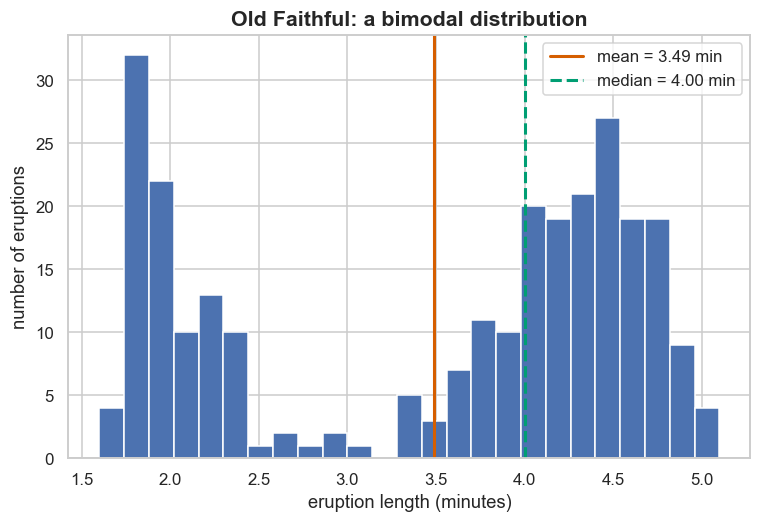

mean = 3.49 min, median = 4.00 min
Eruptions within +/-0.3 min of the MEAN   (3.49):  20 of 272  <- stranded in the sparse valley
Eruptions within +/-0.3 min of the MEDIAN (4.00):  64 of 272  <- up on the long-eruption peak


In [3]:
bins = 25                       # try 20-30; tinker with this
mean_e, median_e = e.mean(), e.median()

fig, ax = plt.subplots()
ax.hist(e, bins=bins, color='#4c72b0', edgecolor='white')
ax.axvline(mean_e,   color='#D55E00', lw=2,            label=f'mean = {mean_e:.2f} min')
ax.axvline(median_e, color='#009E73', lw=2, ls='--',   label=f'median = {median_e:.2f} min')
ax.set_xlabel('eruption length (minutes)'); ax.set_ylabel('number of eruptions')
ax.set_title('Old Faithful: a bimodal distribution')
ax.legend(); plt.show()

near_mean   = ((e > mean_e - 0.3)   & (e < mean_e + 0.3)).sum()
near_median = ((e > median_e - 0.3) & (e < median_e + 0.3)).sum()
print(f"mean = {mean_e:.2f} min, median = {median_e:.2f} min")
print(f"Eruptions within +/-0.3 min of the MEAN   ({mean_e:.2f}): {near_mean:>3} of {len(e)}  <- stranded in the sparse valley")
print(f"Eruptions within +/-0.3 min of the MEDIAN ({median_e:.2f}): {near_median:>3} of {len(e)}  <- up on the long-eruption peak")

**The hook:** look where the **mean (3.49 min, red)** lands — right in the **near-empty valley between the two crowds**. Only about 20 of the 272 eruptions fall within half a minute of it, and the true valley (2.5–3.4 min) holds just 10; an eruption of "about 3.5 minutes" — the so-called average — *almost never happens.* The **median (4.00 min, green)** is the more honest single summary here: it sits up among the common long eruptions (about 64 nearby). But notice the catch — *neither* number can tell you the real story, because there isn't one center.

- **The meaning:** a single center-number assumes there *is* a single center. Here there are two crowds, so the mean gets stranded in the gap between them while the median can only point at one of the two peaks.
- **The interpretation:** a summary number can describe a value that **barely occurs** in the data. The honest description of Old Faithful is "short (~2 min) or long (~4.3 min), rarely in between" — which no single number can say.

**Moral: always plot.** A mean is a fact about the arithmetic, not a promise about the world.

## 3) Symmetric vs skewed — and the mean-vs-median signal

Now switch datasets. **Lending Club** (a peer-to-peer lending company) records each borrower's `annual_income` (self-reported, in dollars) — a textbook case of **right skew**: most people cluster low, but a long tail of high earners stretches far to the right.

- **The math:** *skewness* measures lopsidedness; $0$ is symmetric, positive means a longer **right** tail.
- **The meaning:** the long tail of big values **drags the mean toward it**, while the median (just the middle person) barely budges.
- **The interpretation — a rule of thumb:**
  $$\text{mean} > \text{median} \;\Rightarrow\; \text{right-skewed (long right tail)}.$$

In [4]:
income = loans['annual_income']     # dollars, self-reported
print(f"n = {len(income):,}")
print(f"mean   = ${income.mean():>12,.0f}")
print(f"median = ${income.median():>12,.0f}")
print(f"std    = ${income.std(ddof=1):>12,.0f}")
print(f"min    = ${income.min():>12,.0f}   max = ${income.max():,.0f}")
print(f"skewness = {income.skew():.2f}   (0 = symmetric; big positive = long right tail)")
print()
print("mean > median  ->  " + ("RIGHT-skewed" if income.mean() > income.median() else "not right-skewed"))

n = 10,000
mean   = $      79,222
median = $      65,000
std    = $      64,734
min    = $           0   max = $2,300,000
skewness = 9.03   (0 = symmetric; big positive = long right tail)

mean > median  ->  RIGHT-skewed


The mean (about 79,222 dollars) sits well **above** the median (65,000 dollars), and the skewness is a whopping **9.0**. That gap *is* the skew, expressed in dollars: the average is inflated by a relatively few very high earners.

Let's draw it. The biggest income in the data is 2.3 million dollars, so a raw histogram would be one tall bar at the left and 99% empty space. To make the shape readable we **clip the x-axis at the 99th percentile** — that is, we zoom in on where almost everyone lives. (We're only changing the *view*; no data is deleted.)

Clipping the x-axis at the 99th percentile = $300,000 (for readability only).


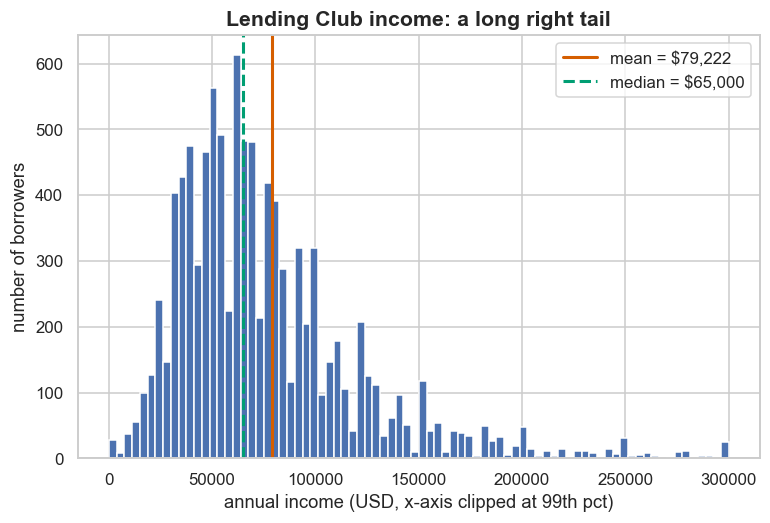

In [5]:
clip = income.quantile(0.99)        # 99th percentile; the view stops here
print(f"Clipping the x-axis at the 99th percentile = ${clip:,.0f} (for readability only).")

fig, ax = plt.subplots()
ax.hist(income, bins=80, range=(0, clip), color='#4c72b0', edgecolor='white')
ax.axvline(income.mean(),   color='#D55E00', lw=2,          label=f'mean = ${income.mean():,.0f}')
ax.axvline(income.median(), color='#009E73', lw=2, ls='--', label=f'median = ${income.median():,.0f}')
ax.set_xlabel('annual income (USD, x-axis clipped at 99th pct)')
ax.set_ylabel('number of borrowers')
ax.set_title('Lending Club income: a long right tail')
ax.legend(); plt.show()

Classic right skew: a tall body of ordinary incomes, then a tail trailing off to the right (and continuing far past where we clipped). The **mean (red) sits to the right of the median (green)** — pulled out by that tail, exactly as the rule of thumb predicts.

## 4) Outliers and the 1.5 × IQR rule

How far is "too far" out in the tail? A standard, automatic flag uses the **IQR** (interquartile range, the width of the middle 50%) from Lesson 1.

- **The math:** with quartiles $Q_1$ (25th pct) and $Q_3$ (75th pct), let $\text{IQR} = Q_3 - Q_1$. A value is flagged as a high outlier if it exceeds the **upper fence**
  $$Q_3 + 1.5 \times \text{IQR}.$$
- **The meaning:** the fence sits one-and-a-half box-widths past the box. The boxplot below draws exactly this: the box is $Q_1$–$Q_3$, the whiskers reach to the fences, and anything past them is plotted as an individual dot.
- **The interpretation:** "outlier" means *unusually far from the bulk* — **not** "wrong" or "error." For income, these are real high earners.

Q1 = $45,000   Q3 = $95,000   IQR = $50,000
Upper fence Q3 + 1.5*IQR = $170,000
Incomes above the fence: 508 of 10,000  (5.1%)


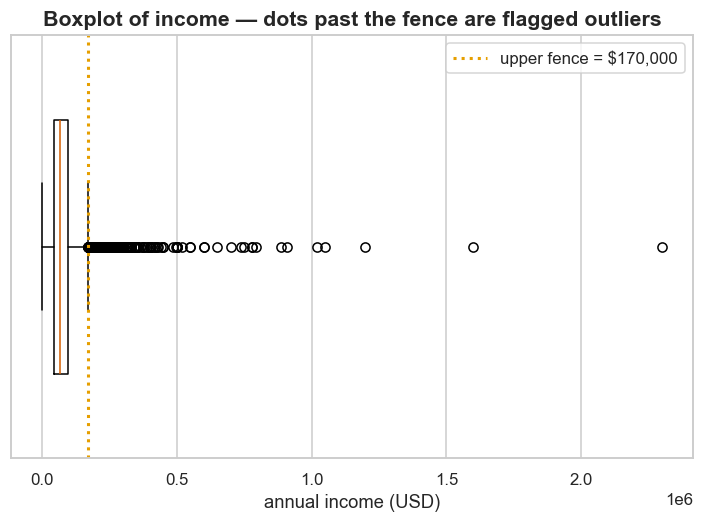

In [6]:
q1, q3 = income.quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_out = (income > upper_fence).sum()

print(f"Q1 = ${q1:,.0f}   Q3 = ${q3:,.0f}   IQR = ${iqr:,.0f}")
print(f"Upper fence Q3 + 1.5*IQR = ${upper_fence:,.0f}")
print(f"Incomes above the fence: {n_out:,} of {len(income):,}  ({n_out/len(income)*100:.1f}%)")

fig, ax = plt.subplots()
ax.boxplot(income, vert=False, widths=0.6, showfliers=True)
ax.axvline(upper_fence, color='#E69F00', lw=2, ls=':', label=f'upper fence = ${upper_fence:,.0f}')
ax.set_xlabel('annual income (USD)')
ax.set_yticks([])
ax.set_title('Boxplot of income — dots past the fence are flagged outliers')
ax.legend(); plt.show()

About **508** borrowers (~5%) sit above the 170,000-dollar fence. The boxplot's swarm of dots on the right is that whole high-earning tail.

These are *not* data errors — they're genuine people with high incomes. The 1.5 × IQR rule is a useful **flag for "look here,"** not a verdict that a value is invalid. With strongly skewed data, expect the rule to flag a fair number of legitimate values on the long side.

## 5) Robust vs non-robust — the billionaire test

A statistic is **robust** if a few extreme values barely move it, and **non-robust** if they yank it around.

Let's run the cleanest possible experiment: remove the **single highest earner** (2.3 million dollars) and recompute. Predict first — which moves more, the mean or the median?

In [7]:
top_idx = income.idxmax()
without_top = income.drop(top_idx)

mean_full,   mean_drop   = income.mean(),   without_top.mean()
median_full, median_drop = income.median(), without_top.median()

print(f"Top earner removed: ${income.max():,.0f}\n")
print(f"{'':10}{'with':>14}{'without':>14}{'change':>14}")
print(f"{'mean':10}${mean_full:>12,.0f}${mean_drop:>13,.0f}${mean_full-mean_drop:>13,.0f}")
print(f"{'median':10}${median_full:>12,.0f}${median_drop:>13,.0f}${median_full-median_drop:>13,.0f}")

Top earner removed: $2,300,000



                    with       without        change
mean      $      79,222$       79,000$          222
median    $      65,000$       65,000$            0


Removing one person out of 10,000 shifts the **mean by about 222 dollars** but moves the **median by 0**. That's the whole idea:

- **Robust** (resists outliers): **median**, **IQR**. They ask "who's in the middle / how wide is the middle?" — extremes don't get a vote on the answer.
- **Non-robust** (sensitive to outliers): **mean**, **standard deviation**, **range**. They use every value, so a single giant can swing them.

**Interpretation:** for skewed money data, the **median** is usually the more honest "typical person." Report the mean *and* the median, and when they disagree, the gap is telling you about the tail.

## 6) z-scores on non-normal data — a ruler, not a probability

A **z-score** rescales a value into "how many standard deviations from the mean":

$$z = \frac{x - \bar{x}}{s}.$$

This is *just arithmetic* — subtract the mean, divide by the SD. It works on **any** numbers, bell-shaped or not. Let's standardize income and find the z-score of the 2.3-million-dollar earner.

In [8]:
z = (income - income.mean()) / income.std(ddof=1)
zmax = z.max()
print(f"Largest income ${income.max():,.0f}  ->  z = {zmax:.1f}")
print(f"That is about {zmax:.0f} standard deviations above the mean.")
print(f"Share of incomes with z > 3: {(z > 3).mean()*100:.1f}%")

Largest income $2,300,000  ->  z = 34.3
That is about 34 standard deviations above the mean.
Share of incomes with z > 3: 1.4%


The top earner sits about **34 standard deviations** above the mean. In a bell curve, $z = 34$ would be so far out it's effectively impossible — yet here it's a real, ordinary-to-flag data point.

- **The meaning:** the z-score correctly says "extremely far from the mean, relative to the typical spread." That much is honest.
- **The interpretation — the crucial caveat:** a big z here does **not** mean "impossible," and it does **not** convert into a tidy probability. That translation ("a z-score tells you the odds") only works when the data is roughly **normal** (the bell curve). This income is wildly skewed, so $z$ is a *distance*, not a *p-value*.

We'll earn the right to turn z-scores into probabilities in **Lesson 9 (the normal distribution)**. For now: z is a ruler. Knowing how far out you are is not the same as knowing how likely it was.

## Now you try

Predict the result, change one thing, then re-run:

1. **Bins change the story.** In the Old Faithful histogram (Section 2), set `bins = 8`, then `bins = 50`. Does the data still look bimodal with very few bins? Predict first, then check your answer against the frequency table from Section 1.
2. **Where to clip.** In Section 3, change `clip = income.quantile(0.99)` to `0.95`, then `0.999`. How does the visible shape — and the apparent size of the tail — change? You're only changing the *view*; the mean and median printed don't move.
3. **Robustness, dialed up.** In Section 5, drop the **top 50** earners instead of one (`without_top = income.drop(income.nlargest(50).index)`) and recompute. How much does the mean move now versus the median?

## What you learned

- A **frequency table / histogram** reveals shape; Old Faithful is **bimodal**, so its **mean** is stranded in the near-empty valley (the "average" eruption barely happens) while the **median** can only sit on one of the two peaks — no single number captures two crowds. **Always plot.**
- **Right skew** = a long right tail; it pulls the **mean above the median**, giving the rule of thumb $\text{mean} > \text{median} \Rightarrow$ right-skewed.
- The **1.5 × IQR rule** flags points past $Q_3 + 1.5\,\text{IQR}$ as outliers — a "look here" flag, not proof of an error; ~508 real high earners got flagged.
- **Robust** statistics (median, IQR) shrug off extremes; **non-robust** ones (mean, SD, range) get dragged — removing one billionaire moved the mean but not the median.
- A **z-score** is just "how many SDs from the mean" and works on any data, but a huge z on **non-normal** data is a *distance*, not a probability (that comes in Lesson 9).

---

**← Previous:** [Lesson 1: Describing a real dataset](01-describing-data.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 3: Relationships: correlation & the regression line](03-relationships-regression.ipynb)

**Same idea, another way:**  [Another dataset →](02-distributions-shape-outliers~another-dataset.ipynb)  ·  [The code behind it →](02-distributions-shape-outliers~the-code.ipynb)